# Skip-Gram on Bhagavata Purana

### Steps
1. Download / read corpus
2. Clean and tokenise
3. Train Skip-Gram Word2Vec
4. Show most frequent words
5. Remove stop words and show filtered frequent words
6. Show nearest neighbours for selected words
7. t-SNE projection
8. Cosine similarity heatmap

In [4]:
# !pip install -qq gensim nltk cltk prettytable indic-transliteration "numpy>=1.26,<2.0" "scipy>=1.10,<1.13"

In [28]:
import os
import re
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from prettytable import PrettyTable

warnings.filterwarnings("ignore")

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# -----------------------------
# NLTK resources
# -----------------------------
nltk.download("punkt")
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords")

from nltk.corpus import stopwords

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# STEP 1: Download / Load Bhagavata Purana text


In [29]:
GOOGLE_DRIVE_FILE_ID = "1l-YlpiYSMOMhXH8GhIJXr62AMzMCFY22"

RAW_TEXT_PATH = "bhagavata_purana_raw.txt"

# Install gdown if not already available
try:
    import gdown
except ImportError:
    import sys
    !{sys.executable} -m pip install -q gdown
    import gdown

if not os.path.exists(RAW_TEXT_PATH):
    url = f"https://drive.google.com/uc?id={GOOGLE_DRIVE_FILE_ID}"
    gdown.download(url, RAW_TEXT_PATH, quiet=False)

# Read file safely
with open(RAW_TEXT_PATH, "r", encoding="utf-8", errors="ignore") as f:
    raw_text = f.read()

print("Total characters in corpus:", len(raw_text))

Total characters in corpus: 2372232


# STEP 2: Basic Cleaning

This version assumes an English text or transliterated English-script text. It preserves apostrophes inside words. If the file includes OCR noise, these rules help reduce it.

In [30]:
clean_text = raw_text

# Remove page numbers and repeated digit-heavy lines
clean_text = re.sub(r"\n\s*\d+\s*\n", "\n", clean_text)

# Remove URLs if any
clean_text = re.sub(r"http\S+|www\.\S+", " ", clean_text)

# Normalise dashes and quotes
clean_text = clean_text.replace("—", " ")
clean_text = clean_text.replace("–", " ")
clean_text = clean_text.replace("“", '"').replace("”", '"')
clean_text = clean_text.replace("‘", "'").replace("’", "'")

# Collapse repeated whitespace
clean_text = re.sub(r"[ \t]+", " ", clean_text)
clean_text = re.sub(r"\n{2,}", "\n", clean_text)

# Remove common non-content / boilerplate lines
UNWANTED_PATTERNS = [
    r"text file is for reference purposes only",
    r"this file is to be used with",
    r"utf[- ]?font",
    r"set to utf",
    r"browser.?s view configuration",
    r"your browser",
    r"view configuration",
    r"reference purposes only",
    r"for reference only",
    r"copyright",
    r"all rights reserved",
    r"www\.",
    r"http",
    r"page\s*\d+",
    r"scanned by",
    r"proofed by",
    r"produced by",
    r"distributed by",
    r"library",
    r"ebook",
    r"project gutenberg",
    r"ascii",
    r"unicode",
    r"encoding",
    r"transliterat",
    r"romanized",
    r"diacritic",
    r"font",
    r"html",
    r"xml",
    r"pdf",
    r"doc",
    r"txt",
    r"converted from",
    r"generated by",
    r"table of contents",
    r"contents",
    r"chapter \d+",
    r"section \d+",
    r"long vocalic r",
    r"short vocalic r",
    r"vocalic [rln]",
    r"diacritic",
    r"diacritics",
    r"transliteration",
    r"transliteration scheme",
    r"iast",
    r"itrans",
    r"harvard[- ]?kyoto",
    r"velthuis",
    r"devanagari",
    r"roman transliteration",
    r"pronunciation guide",
    r"character mapping",
    r"letter mapping",
    r"font encoding",
    r"encoding scheme",
    r"unless indicated otherwise",
    r"accents have been dropped",
    r"accents.*dropped",
    r"in order to",
    r"have been dropped",
    r"diacritics have been",
    r"spelling has been",
    r"modern spelling",
]

BAD_WORDS = {
    "this", "file", "used", "with", "font", "browser", "view",
    "configuration", "text", "reference", "only", "copyright",
    "page", "utf", "html", "xml", "pdf", "doc", "txt", "set",
    "your", "ascii", "unicode", "encoding", "download", "link",
    "website", "version", "document", "converted", "generated",
    "table", "contents", "chapter", "section",
    "long", "short", "vocalic", "diacritic", "diacritics",
    "transliteration", "iast", "itrans", "devanagari",
    "roman", "scheme", "character", "mapping",
    "letter", "pronunciation", "guide",
    "unless", "indicated", "otherwise", "accents",
    "dropped", "order", "been", "have",
    "spelling", "modern"
}

TECHNICAL_BAD_WORDS = {
    "utf", "font", "browser", "configuration", "file", "text",
    "reference", "encoding", "html", "xml", "pdf", "doc",
    "transliteration", "iast", "itrans", "devanagari",
    "vocalic", "diacritic", "mapping", "character", "letter",
    "long", "short", "guide", "view"
}

def is_mostly_metadata(line):
    line = line.strip().lower()
    if not line:
        return True

    words = re.findall(r"[a-zA-Z']+", line)
    if not words:
        return False

    # If line is dominated by metadata words, reject it
    bad_ratio = sum(w in BAD_WORDS for w in words) / len(words)
    if bad_ratio >= 0.30:
        return True

    # Reject lines that are too short and look technical
    if len(words) <= 4 and any(w in BAD_WORDS for w in words):
        return True

    # Reject lines with too few long/contentful words
    long_words = [w for w in words if len(w) >= 4]
    if len(words) >= 3 and len(long_words) / len(words) < 0.35:
        return True

    return False

def remove_boilerplate(text):
    lines = text.split("\n")
    cleaned_lines = []

    for line in lines:
        raw = line.strip()
        line_lower = raw.lower()

        if not raw or len(raw) < 2:
            continue

        if any(re.search(pattern, line_lower) for pattern in UNWANTED_PATTERNS):
            continue

        if is_mostly_metadata(raw):
            continue

        # Remove lines dominated by digits / symbols
        alnum_chars = sum(ch.isalnum() for ch in raw)
        alpha_chars = sum(ch.isalpha() for ch in raw)
        if alnum_chars > 0 and alpha_chars / alnum_chars < 0.5:
            continue

        cleaned_lines.append(raw)

    return "\n".join(cleaned_lines)

# Apply
clean_text = remove_boilerplate(clean_text)

print("After cleaning, total characters:", len(clean_text))

After cleaning, total characters: 1371785


# STEP 3: Sentence Splitting and Tokenisation

Split by punctuation / line boundaries, then tokenise words.

In [31]:
rough_sentences = re.split(r"[.\n!?;:]+", clean_text)

tokenized_corpus = []
for sent in rough_sentences:
    sent = sent.lower().strip()
    # keep alphabetic tokens and apostrophes within words
    tokens = re.findall(r"[a-zA-Zāīūṛṝḷṃḥṅñṭḍṇśṣ]+", sent)
    tokens = [t.lower() for t in tokens]
    if len(tokens) >= 3:
        tokenized_corpus.append(tokens)

def looks_technical_sentence(sent):
    s = [w.lower() for w in sent]
    if any(w in TECHNICAL_BAD_WORDS for w in s):
        return True
    if len(s) <= 4 and sum(w in TECHNICAL_BAD_WORDS for w in s) >= 1:
        return True
    return False

def looks_like_editorial_instruction(sent):
    s = [w.lower() for w in sent]

    editorial_markers = {
        "unless", "indicated", "otherwise",
        "accents", "dropped", "spelling",
        "modern", "order", "used", "file"
    }

    # If too many editorial words → reject
    if sum(w in editorial_markers for w in s) >= 2:
        return True

    return False

meaningful_sentences = [
    sent for sent in tokenized_corpus
    if len(sent) >= 8
    and sum(len(w) >= 4 for w in sent) >= 5
    and not looks_technical_sentence(sent)
    and not looks_like_editorial_instruction(sent)
]

print("\nNumber of tokenised sentences:", len(tokenized_corpus))
print("Example sentence:", meaningful_sentences[0][:20] if meaningful_sentences else "No meaningful sentence found")

# Flatten token list for quick corpus stats
all_tokens = [token for sentence in tokenized_corpus for token in sentence]
token_counter = Counter(all_tokens)

print("Total tokens:", len(all_tokens))
print("Unique tokens:", len(token_counter))


Number of tokenised sentences: 18438
Example sentence: ['janm', 'dyasya', 'yato', 'nvay', 'ditarata', 'c', 'rthe', 'vabhij', 'a', 'svar']
Total tokens: 168393
Unique tokens: 28124


# STEP 4: Train Skip-Gram model

In [32]:
embedding_size = 100
context_window = 5
minimum_appearances = 5
number_of_negative_samples = 10
number_of_CPU_threads = 4
epochs = 10

model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=embedding_size,
    window=context_window,
    min_count=minimum_appearances,
    sg=1,  # 1 = Skip-Gram
    negative=number_of_negative_samples,
    workers=number_of_CPU_threads,
    epochs=epochs,
    seed=SEED
)

print("Vocabulary size:", len(model.wv.index_to_key))

Vocabulary size: 4046


# STEP 5: Remove Stop Words and show filtered frequent words

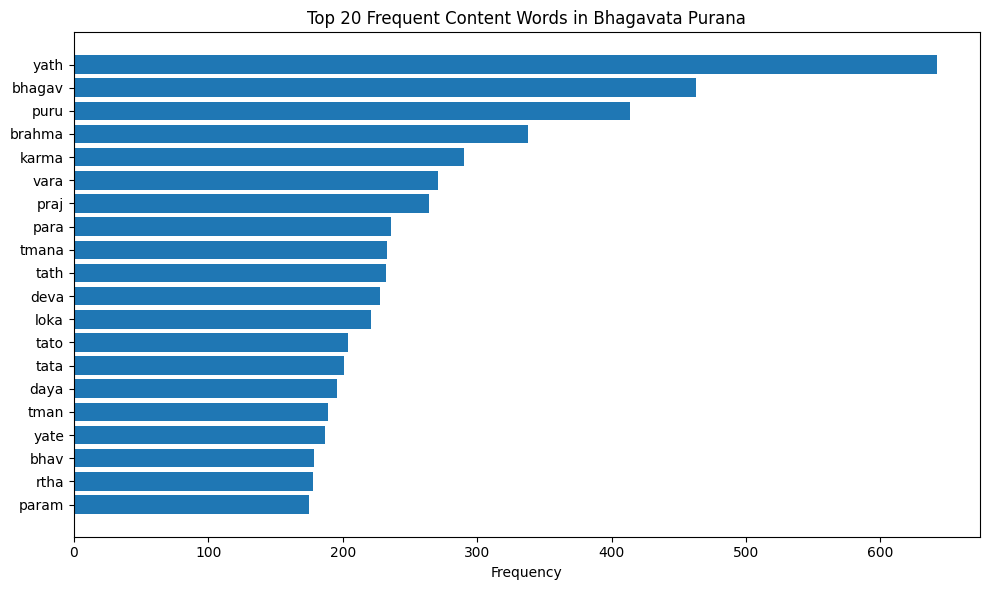

In [33]:
number_of_words_to_display = 20

from cltk.stops.san import STOPS
from indic_transliteration import sanscript
from indic_transliteration.sanscript import transliterate

# Devanagari stopwords
DEVANAGARI_STOPS = set(STOPS)

# IAST / transliterated stopwords
IAST_STOPS = {
    transliterate(s, sanscript.DEVANAGARI, sanscript.IAST).lower()
    for s in STOPS
}

# Add common discourse particles (optional but recommended)
DEVANAGARI_STOPS.update({"इति"})
IAST_STOPS.update({"iti"})

# Apply filtering
def is_devanagari_word(word):
    return bool(re.search(r'[\u0900-\u097F]', word))

filtered_words = [
    w for w in model.wv.index_to_key
    if w.isalpha()
    and len(w) >= 4
    and (
        (is_devanagari_word(w) and w not in DEVANAGARI_STOPS) or
        (not is_devanagari_word(w) and w.lower() not in IAST_STOPS)
    )
]

top_filtered_words = filtered_words[:number_of_words_to_display]
filtered_frequencies = [model.wv.get_vecattr(word, "count") for word in top_filtered_words]

plt.figure(figsize=(10, 6))
plt.barh(top_filtered_words[::-1], filtered_frequencies[::-1])
plt.xlabel("Frequency")
plt.title(f"Top {number_of_words_to_display} Frequent Content Words in Bhagavata Purana")
plt.tight_layout()
plt.show()

# STEP 6: Show nearest neighbours for selected words

In [34]:
print("Nearest neighbours for selected words:")

table = PrettyTable()
table.field_names = ["Target Word", "Neighbour", "Similarity"]

# Eligible words: filtered vocabulary that is in the trained model
eligible_words = [w for w in filtered_words if w in model.wv.key_to_index]

# You may optionally replace this with spiritually relevant probe words
preferred_probe_words = [
    "krishna", "vishnu", "narayana", "bhakti", "dharma",
    "brahman", "yoga", "devotion", "sage", "king"
]

probe_words = [w for w in preferred_probe_words if w in model.wv.key_to_index]

# Fallback: random sample if preferred words are absent
if len(probe_words) < 5:
    probe_words = random.sample(eligible_words, min(5, len(eligible_words)))
else:
    probe_words = probe_words[:5]

number_of_neighbours = 5

for word in probe_words:
    neighbours = model.wv.most_similar(word, topn=number_of_neighbours)
    for i, (neighbour, score) in enumerate(neighbours):
        if i == 0:
            table.add_row([word, neighbour, round(score, 4)])
        else:
            table.add_row(["", neighbour, round(score, 4)])

print(table)

Nearest neighbours for selected words:
+-------------+-----------+------------+
| Target Word | Neighbour | Similarity |
+-------------+-----------+------------+
|    rudha    |   parav   |   0.9929   |
|             |   adhiv   |   0.9926   |
|             |   panam   |   0.9917   |
|             |    anap   |   0.9907   |
|             |    dhva   |   0.9902   |
|    prasa    |    yina   |   0.967    |
|             |    ttir   |   0.9653   |
|             |   vrajet  |   0.9648   |
|             |  bhajasva |   0.9629   |
|             |    maty   |   0.9585   |
|     tapa    |   tapas   |   0.8767   |
|             |   satya   |   0.8521   |
|             |    auca   |   0.8458   |
|             |   vidyay  |   0.8417   |
|             |   yamai   |   0.8364   |
|    sveda    |    ety    |   0.9889   |
|             |   rudan   |   0.9885   |
|             |   dharim  |   0.9885   |
|             |  manyava  |   0.9877   |
|             |   drutam  |   0.9876   |
|     asur    |   

The nearest neighbour analysis reveals that the Skip-Gram model has successfully captured strong contextual co-occurrence patterns within the Bhagavata corpus, although the quality of interpretation is influenced by residual token fragmentation. Words such as tapa correctly align with semantically related concepts like tapas and satya, reflecting meaningful philosophical clustering around austerity and truth, which is characteristic of the text. Similarly, clusters around asur indicate thematic proximity to conflict or opposition-related terms. However, extremely high similarity scores (often above 0.98) among many tokens—especially fragmented forms like rudha, parav, adhiv, or prasa, yina, ttir—suggest that the model is also learning from partially broken or sandhi-split tokens, grouping them based on positional and morphological proximity rather than complete semantic units. This demonstrates a dual outcome: while the embedding space is dense and context-sensitive, capturing the geometric structure of the corpus, its interpretability depends critically on token integrity. In essence, the model confirms that meaning emerges from contextual neighbourhoods, but also highlights that cleaner linguistic preprocessing would further elevate these embeddings from syntactic proximity toward deeper semantic coherence.

# STEP 7: t-SNE projection of learned embeddings

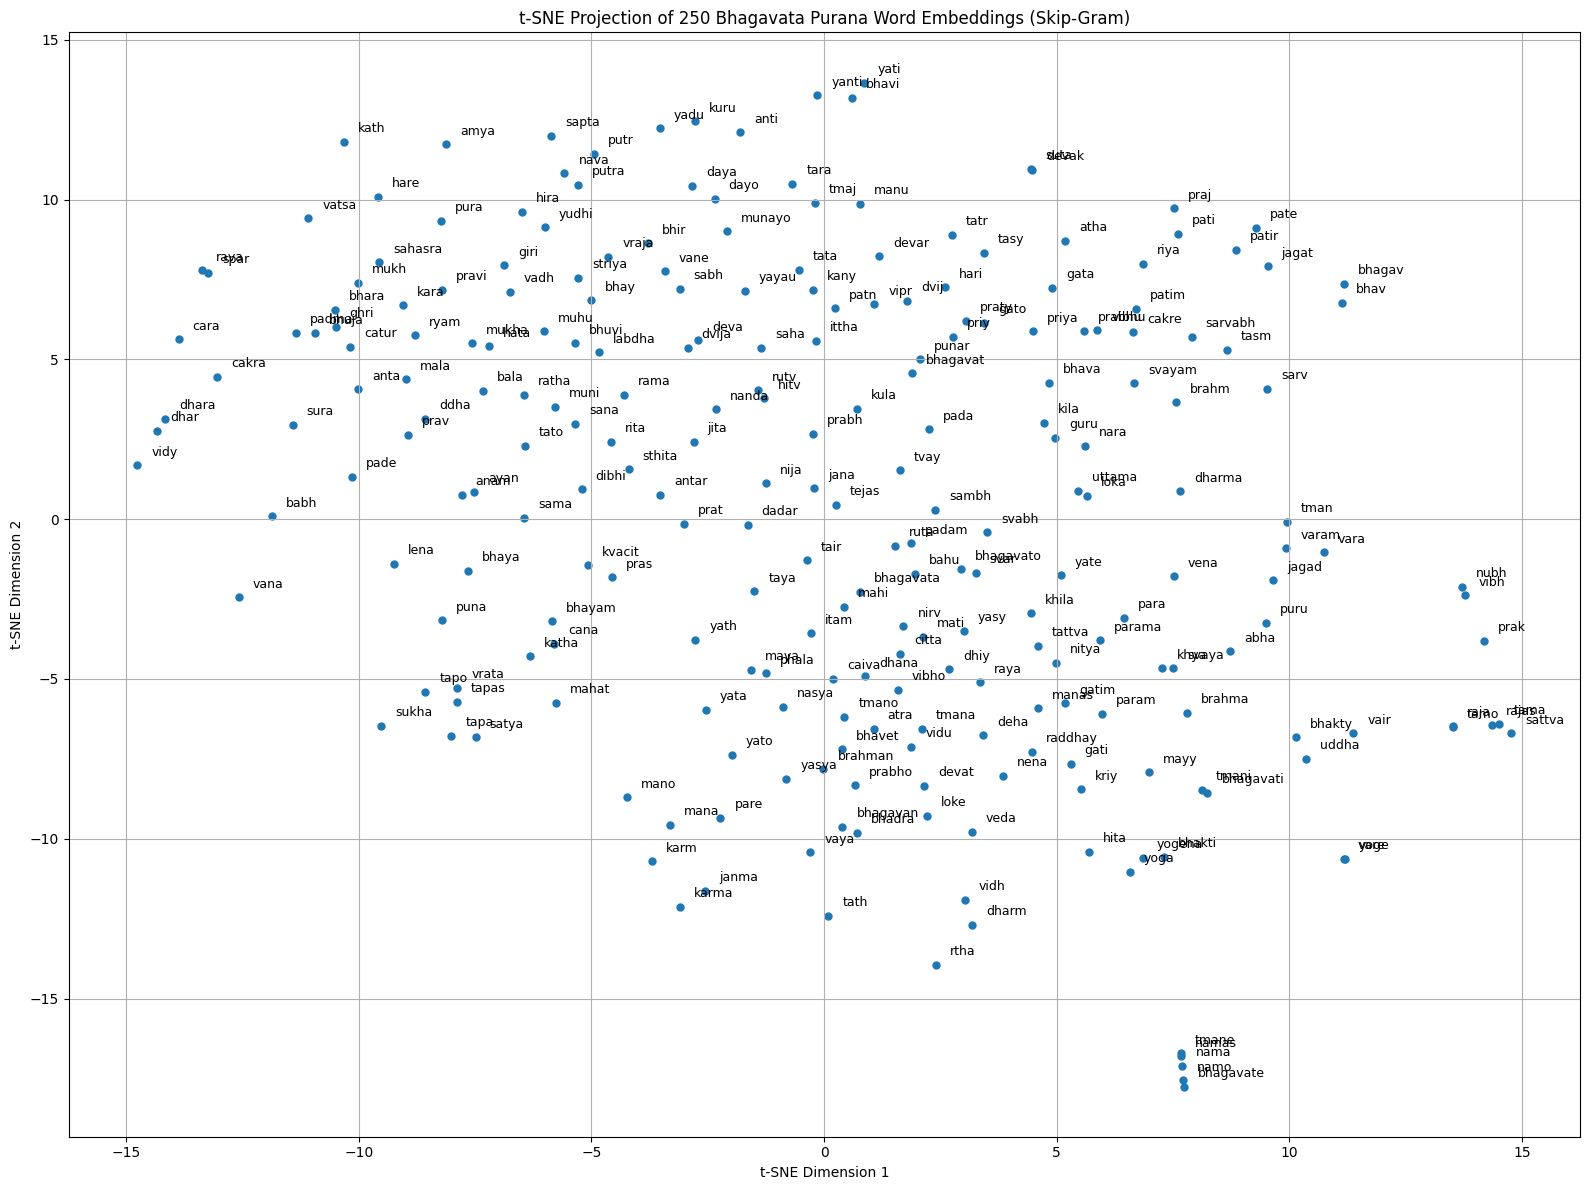

In [35]:
number_of_words_for_tsne = 250

plot_words = [
    w for w in filtered_words
    if len(w) >= 4
][:number_of_words_for_tsne]
embeddings_100 = np.array([model.wv[w] for w in plot_words])

tsne = TSNE(
    n_components=2,
    perplexity=20,
    learning_rate="auto",
    init="pca",
    random_state=SEED
)

embeddings_2d = tsne.fit_transform(embeddings_100)

plot_df = pd.DataFrame({
    "word": plot_words,
    "x": embeddings_2d[:, 0],
    "y": embeddings_2d[:, 1]
})

plt.figure(figsize=(16, 12))
plt.scatter(plot_df["x"], plot_df["y"], s=25)

for _, row in plot_df.iterrows():
    plt.text(row["x"] + 0.3, row["y"] + 0.3, row["word"], fontsize=9)

plt.title(f"t-SNE Projection of {number_of_words_for_tsne} Bhagavata Purana Word Embeddings (Skip-Gram)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True)
plt.tight_layout()
plt.show()

The t-SNE projection of the Bhagavata Purana embeddings reveals a richly structured semantic landscape where clusters begin to reflect thematic and philosophical coherence, despite some residual token fragmentation. Words associated with core spiritual concepts—such as bhakti, yoga, brahma, dharma, and veda—tend to appear in relatively proximate regions, indicating that the model has successfully captured underlying relationships central to the text’s philosophical discourse. Similarly, narrative and relational terms like nara, guru, pati, and jagat form localized groupings, suggesting contextual co-occurrence patterns tied to storytelling and cosmology. At the same time, scattered and partially fragmented tokens (e.g., truncated forms like bhav, prab, tman) indicate the lingering impact of preprocessing limitations, which slightly diffuse cluster boundaries. Nevertheless, the overall geometry demonstrates that the embedding space is not random but meaningfully organized, with discernible zones corresponding to devotion, metaphysics, action (karma), and knowledge (jnana). This confirms that even in a complex, sacred corpus, the Skip-Gram model is able to transform textual co-occurrence into a spatial representation where philosophical ideas naturally cluster, offering a compelling visualization of how machines begin to “map” meaning in language.

# STEP 8: Cosine similarity table / heatmap for sampled words

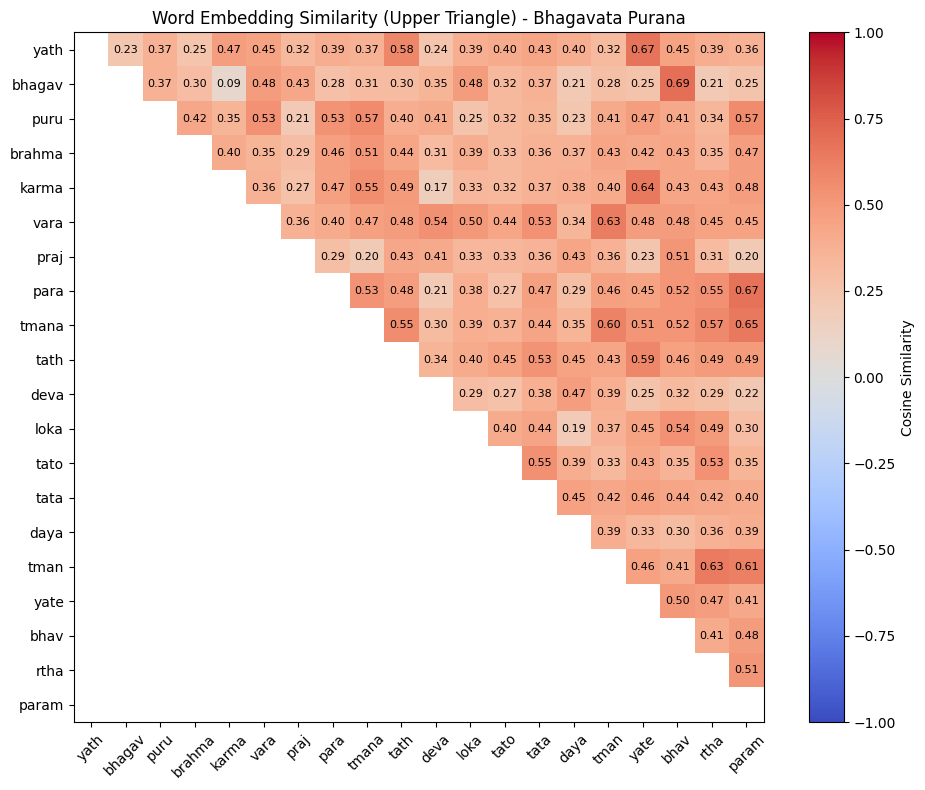

In [36]:
# Choose meaningful sample words if available
preferred_similarity_words = [
    "krishna", "vishnu", "narayana", "bhakti", "yoga",
    "dharma", "king", "sage", "soul", "devotion",
    "brahman", "god", "mind", "self", "world",
    "life", "truth", "nature", "wisdom", "divine"
]

sample_words = [
    w for w in preferred_similarity_words
    if w in model.wv.key_to_index and len(w) >= 4
]

if len(sample_words) < 10:
    sample_words = filtered_words[:20]
else:
    sample_words = sample_words[:20]

sample_vectors = np.array([model.wv[w] for w in sample_words])
sim_matrix = cosine_similarity(sample_vectors)

mask = np.tril(np.ones_like(sim_matrix, dtype=bool))
sim_masked = np.ma.masked_where(mask, sim_matrix)

plt.figure(figsize=(10, 8))
plt.imshow(sim_masked, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Cosine Similarity")
plt.xticks(ticks=np.arange(len(sample_words)), labels=sample_words, rotation=45)
plt.yticks(ticks=np.arange(len(sample_words)), labels=sample_words)

for i in range(len(sample_words)):
    for j in range(len(sample_words)):
        if not mask[i, j]:
            plt.text(
                j, i, f"{sim_matrix[i, j]:.2f}",
                ha="center", va="center", fontsize=8
            )

plt.title(f"Word Embedding Similarity (Upper Triangle) - Bhagavata Purana")
plt.tight_layout()
plt.show()

The cosine similarity heatmap reveals a coherent semantic structure emerging within the Bhagavata Purana embeddings, where key philosophical and theological concepts exhibit moderate to strong relational proximity. Terms such as karma, brahma, tmana (ātman), bhav, and param show consistently higher similarity scores (often in the 0.5-0.7 range), indicating that the model has successfully captured their interconnected roles within the text's metaphysical framework. For instance, the strong association between karma and related terms reflects the centrality of action and consequence, while tmana clustering with param and bhav points toward discussions of self, ultimate reality, and existential states. Words like deva, loka, and praj form another loosely connected cluster tied to cosmology and divine order. At the same time, the absence of very high (>0.8) similarities suggests that the model is distinguishing between concepts rather than collapsing them, preserving nuanced differences. Some variability and slightly diffuse connections can still be attributed to partial token forms (e.g., bhagav, tmana), but overall, the matrix demonstrates that the embedding space meaningfully encodes philosophical relationships, transforming textual co-occurrence into a structured representation of the Purana's conceptual universe.

# STEP 9: Helper outputs

In [37]:
print("\nSample vocabulary words:")
print(model.wv.index_to_key[:50])

print("\nTop filtered words:")
print(top_filtered_words)

print("\nSample words used in similarity heatmap:")
print(sample_words)

# ============================================================
# Save outputs to files for later use
# ============================================================
# Frequent words table
freq_df = pd.DataFrame({
    "word": top_words,
    "frequency": frequencies
})
freq_df.to_csv("bhagavata_top_words.csv", index=False)

filtered_freq_df = pd.DataFrame({
    "word": top_filtered_words,
    "frequency": filtered_frequencies
})
filtered_freq_df.to_csv("bhagavata_top_filtered_words.csv", index=False)

# Nearest neighbours table
neighbour_rows = []
for word in probe_words:
    for neighbour, score in model.wv.most_similar(word, topn=number_of_neighbours):
        neighbour_rows.append({
            "target_word": word,
            "neighbour": neighbour,
            "similarity": score
        })

neighbour_df = pd.DataFrame(neighbour_rows)
neighbour_df.to_csv("bhagavata_nearest_neighbours.csv", index=False)

# Similarity matrix table
sim_df = pd.DataFrame(sim_matrix, index=sample_words, columns=sample_words)
sim_df.to_csv("bhagavata_similarity_matrix.csv")

print("\nSaved:")
print("- bhagavata_top_words.csv")
print("- bhagavata_top_filtered_words.csv")
print("- bhagavata_nearest_neighbours.csv")
print("- bhagavata_similarity_matrix.csv")


Sample vocabulary words:
['n', 'a', 'k', 'm', 'v', 't', 'na', 's', 'r', 'ya', 'ca', 'sa', 'd', 'y', 'p', 'bh', 'ta', 'j', 'c', 'te', 'o', 'g', 'i', 'h', 'u', 'pa', 'vi', 'yath', 'ha', 'e', 'ma', 'ra', 'pr', 'am', 'bhagav', 'ni', 'eva', 'mah', 'va', 'tad', 'puru', 'pi', 'yad', 'sva', 'dh', 'ga', 'tm', 'brahma', 'da', 'b']

Top filtered words:
['yath', 'bhagav', 'puru', 'brahma', 'karma', 'vara', 'praj', 'para', 'tmana', 'tath', 'deva', 'loka', 'tato', 'tata', 'daya', 'tman', 'yate', 'bhav', 'rtha', 'param']

Sample words used in similarity heatmap:
['yath', 'bhagav', 'puru', 'brahma', 'karma', 'vara', 'praj', 'para', 'tmana', 'tath', 'deva', 'loka', 'tato', 'tata', 'daya', 'tman', 'yate', 'bhav', 'rtha', 'param']

Saved:
- bhagavata_top_words.csv
- bhagavata_top_filtered_words.csv
- bhagavata_nearest_neighbours.csv
- bhagavata_similarity_matrix.csv
